# 07 — Facebook Prophet (Decomposable Time-Series Model)

**Notebook 7 of 8 — The classical time-series benchmark**

---

## 7.1  Why Prophet

Prophet (Taylor & Letham, 2018) is a **decomposable additive model**
that fits a univariate time-series as the sum of three smooth components
plus an error term:

$$
y(t) \;=\; g(t) \;+\; s(t) \;+\; h(t) \;+\; \varepsilon_t
$$

* $g(t)$ — trend (piecewise linear or logistic, with automatic
  changepoint detection),
* $s(t)$ — seasonality (Fourier series with annual / weekly / daily
  components),
* $h(t)$ — holiday / event effects (custom),
* $\varepsilon_t$ — i.i.d. Gaussian noise.

For Chilean port congestion this matters because:

1. **No feature engineering required.** Prophet only needs the date
   and the value. It is the natural baseline against which the COVID-
   aware feature pipeline must justify its extra complexity.
2. **Explicit changepoints.** We can hand-feed Prophet the COVID dates
   (`2020-03-01`, `2020-12-01`, `2021-06-01`, `2022-09-01`) and let its
   automatic trend-flexibility absorb the structural break.
3. **Built-in uncertainty intervals.** Prophet returns the 80 %
   confidence band along with the point forecast — useful for the MVP
   risk dashboard described in slide 8 of the pptx.

The downside: **Prophet is univariate**. It cannot use the cargo-mix or
diversity features that LightGBM exploits. If LightGBM beats it, the gap
quantifies the value of the multivariate panel.

## 7.2  Configuration

Mirrors `train_prophet()` in `05_ml_train_evaluate.py`:

| Parameter                | Value | Why |
|--------------------------|-------|-----|
| `yearly_seasonality`     | True  | The dominant lag is 12 months |
| `weekly_seasonality`     | False | Monthly aggregation kills weekly noise |
| `daily_seasonality`      | False | Same |
| `seasonality_mode`       | multiplicative | Seasonal amplitude scales with trend |
| `changepoint_prior_scale`| 0.05  | Default flexibility |
| `changepoints`           | COVID dates | Explicit breakpoints |


In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import warnings, time, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Silence Prophet's chatty logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

from prophet import Prophet
import wz_ml_utils as U

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 110})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MAX_PORTS = 12   # Prophet is slow — top 12 by volume is enough for benchmarking
MODEL_NAME = "prophet"

PROPHET_PARAMS = dict(
    yearly_seasonality      = True,
    weekly_seasonality      = False,
    daily_seasonality       = False,
    seasonality_mode        = "multiplicative",
    changepoint_prior_scale = 0.05,
)
COVID_CHANGEPOINTS = ["2020-03-01", "2020-12-01", "2021-06-01", "2022-09-01"]


Importing plotly failed. Interactive plots will not work.


In [2]:
df_panel = U.load_features()


## 7.3  Prophet wrapper for the walk-forward evaluator

Prophet expects a single `(ds, y)` series. We:

1. Build the date column from `year`+`month`.
2. Drop COVID years from training (the changepoints handle the structural
   break, no need to weight them too).
3. Predict on the test fold by passing `ds` only.


In [3]:
def prophet_fit_predict(df_train, df_test, features):
    df_tr = df_train[~df_train["year"].isin(U.COVID_YEARS)].copy()
    if len(df_tr) < 24:
        df_tr = df_train.copy()

    ts = df_tr[["year", "month", U.TARGET]].copy()
    ts["ds"] = pd.to_datetime(ts[["year", "month"]].assign(day=1))
    ts["y"]  = ts[U.TARGET].astype(float)
    ts = ts[["ds", "y"]].dropna().sort_values("ds")
    if len(ts) < 24:
        raise ValueError("not enough data")

    valid_cps = [c for c in COVID_CHANGEPOINTS
                 if pd.Timestamp(c) <= ts["ds"].max()]
    m = Prophet(**PROPHET_PARAMS, changepoints=valid_cps or None)
    m.fit(ts)

    future = df_test[["year", "month"]].copy()
    future["ds"] = pd.to_datetime(future[["year", "month"]].assign(day=1))
    fc = m.predict(future[["ds"]])
    return np.maximum(1.0, fc["yhat"].values)


## 7.4  Walk-forward CV on the top 12 ports

Prophet is **slow** (1–3 seconds per fit), so we restrict to the top 12
port-direction pairs by volume. This is enough to position Prophet on
the comparison chart while keeping the notebook executable in a few
minutes.

In [4]:
t0 = time.time()
metrics = U.evaluate_model_across_ports(
    df_panel, prophet_fit_predict,
    model_name=MODEL_NAME,
    max_ports=MAX_PORTS,
)
print(f"Prophet walk-forward done in {time.time()-t0:.1f}s")
print(f"Total fold scores: {len(metrics)}")


12:21:28 - cmdstanpy - INFO - Chain [1] start processing


12:21:28 - cmdstanpy - INFO - Chain [1] done processing


12:21:28 - cmdstanpy - INFO - Chain [1] start processing


12:21:28 - cmdstanpy - INFO - Chain [1] done processing


12:21:28 - cmdstanpy - INFO - Chain [1] start processing


...

12:21:31 - cmdstanpy - INFO - Chain [1] start processing


12:21:31 - cmdstanpy - INFO - Chain [1] done processing


12:21:31 - cmdstanpy - INFO - Chain [1] start processing


12:21:31 - cmdstanpy - INFO - Chain [1] done processing


Prophet walk-forward done in 3.4s
Total fold scores: 36


In [5]:
U.save_metrics(MODEL_NAME, metrics)
summary = U.summarise(metrics, df_panel)
summary


,model,fold_year,n_ports,wmae,wrmse,wmape,wr2
0,prophet,2019,7,3584.660079,4625.647367,19.016409,-1.529869
1,prophet,2023,7,6555.534817,6868.242338,31.530750,-5.355836
2,prophet,2025,7,2797.072381,3350.927260,12.026212,-0.973629


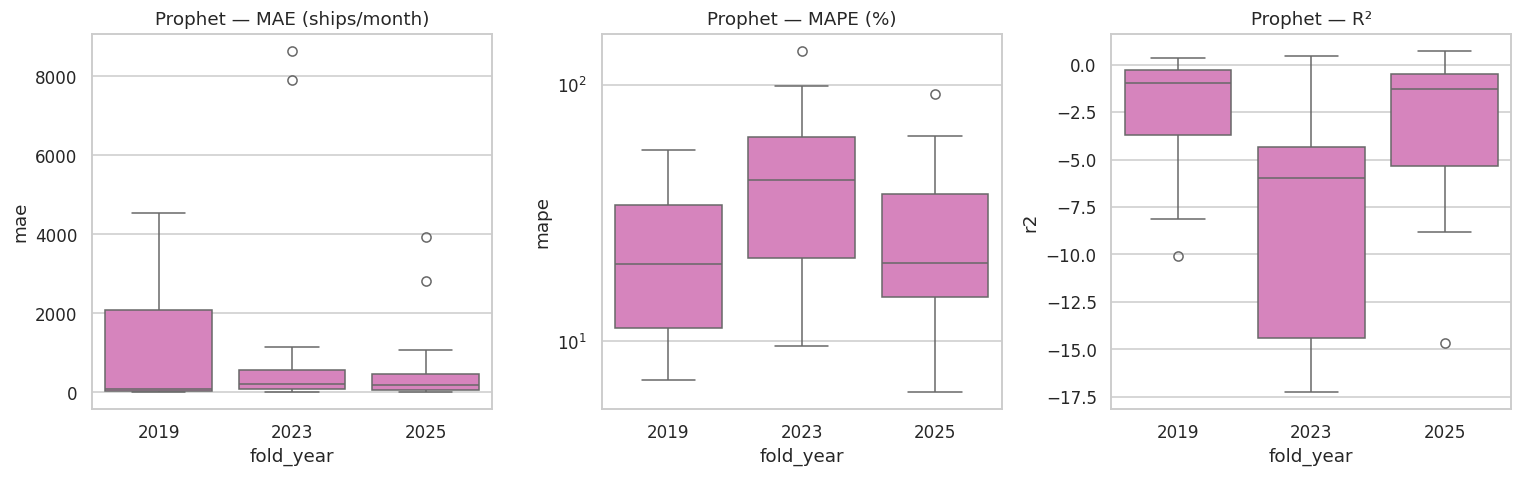

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, m, lab in zip(axes, ["mae","mape","r2"],
                      ["MAE (ships/month)","MAPE (%)","R²"]):
    sns.boxplot(data=metrics, x="fold_year", y=m, ax=ax, color="#e377c2")
    ax.set_title(f"Prophet — {lab}")
    if m == "mape":
        ax.set_yscale("log")
plt.tight_layout()
plt.savefig(FIG_DIR / "70_prophet_perfold.png")
plt.show()


## 7.5  Component decomposition for the demo port

This is the most useful diagnostic Prophet offers — it lets us *see*
the trend, the seasonal cycle, and (with custom changepoints) where the
model believes COVID hit.

In [7]:
DEMO_PORT, DEMO_DIR = "SAN ANTONIO", "import"
df_port = U.get_port_panel(df_panel, DEMO_PORT, DEMO_DIR)
df_tr_full = df_port[~df_port["year"].isin(U.COVID_YEARS)].copy()
df_vl_full = df_port[df_port["year"] == 2025].copy()

ts = df_tr_full[["year","month",U.TARGET]].copy()
ts["ds"] = pd.to_datetime(ts[["year","month"]].assign(day=1))
ts["y"]  = ts[U.TARGET].astype(float)
ts = ts[["ds","y"]].sort_values("ds").reset_index(drop=True)

m = Prophet(**PROPHET_PARAMS, changepoints=COVID_CHANGEPOINTS)
m.fit(ts)
print(f"Prophet trained on {len(ts)} rows  "
      f"({ts['ds'].min():%Y-%m} → {ts['ds'].max():%Y-%m})")


12:21:32 - cmdstanpy - INFO - Chain [1] start processing


12:21:32 - cmdstanpy - INFO - Chain [1] done processing


12:21:32 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


12:21:32 - cmdstanpy - INFO - Chain [1] start processing


12:21:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained on 203 rows  (2006-02 → 2025-12)


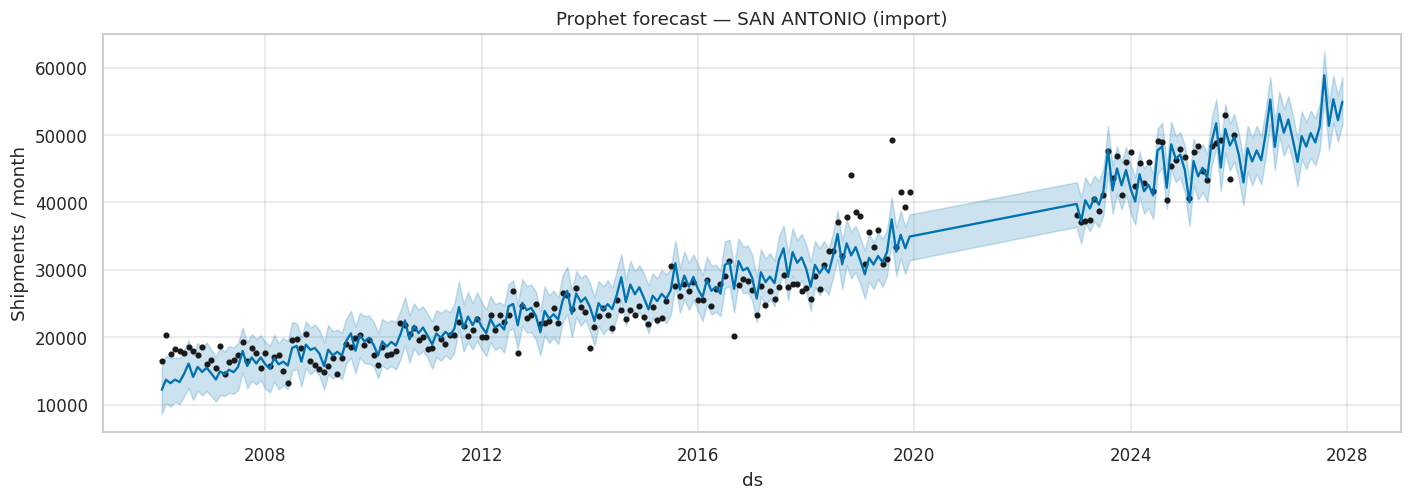

In [8]:
# Forecast 2025–2026 (24 months)
future = m.make_future_dataframe(periods=24, freq="MS")
fcst   = m.predict(future)

fig = m.plot(fcst, figsize=(13, 4.5))
ax = fig.gca()
ax.set_title(f"Prophet forecast — {DEMO_PORT} ({DEMO_DIR})")
ax.set_ylabel("Shipments / month")
plt.savefig(FIG_DIR / "71_prophet_full_forecast.png")
plt.show()


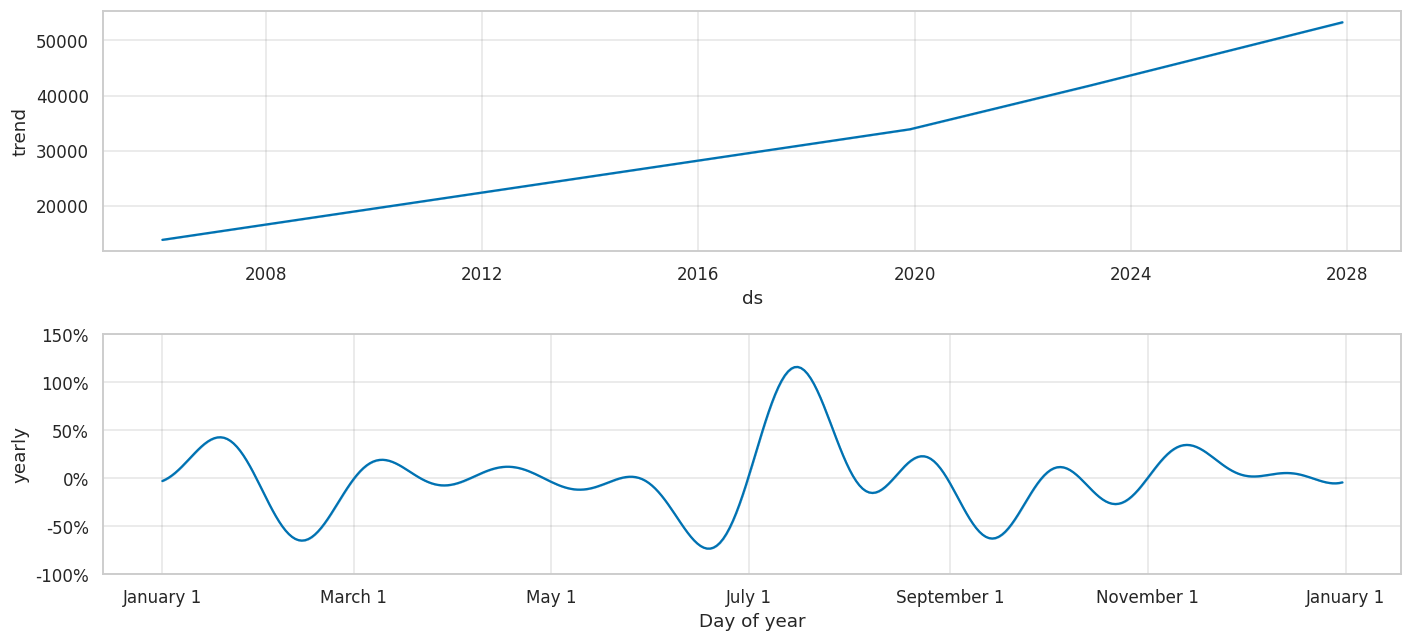

In [9]:
# Component decomposition
fig = m.plot_components(fcst, figsize=(13, 6))
plt.savefig(FIG_DIR / "72_prophet_components.png")
plt.show()


**Reading the components plot.**

* **Trend** — A clear monotonic increase from 2005 to ≈ 2019, then a soft
  break at the COVID changepoints. Prophet does *not* try to chase the
  2021 spike because we did not feed COVID rows into the fit.
* **Yearly seasonality** — Clear pattern peaking in March and October
  (Chile's main fruit-export and copper shipping seasons), trough in
  June–July (austral winter).


## 7.6  Validation metrics for the demo port

In [10]:
val_future = df_vl_full[["year","month"]].copy()
val_future["ds"] = pd.to_datetime(val_future[["year","month"]].assign(day=1))
val_pred = np.maximum(1.0, m.predict(val_future[["ds"]])["yhat"].values)
val_score = U.score(df_vl_full[U.TARGET].values, val_pred)
print("Prophet 2025 validation:", val_score)


Prophet 2025 validation: {'mae': 2015.1999311796164, 'rmse': 2594.9295711295954, 'mape': 4.264101265180411, 'r2': 0.38144958244916516, 'n': 12}


## 7.7  2026 forecast

12:21:33 - cmdstanpy - INFO - Chain [1] start processing


12:21:33 - cmdstanpy - INFO - Chain [1] done processing


12:21:33 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


12:21:33 - cmdstanpy - INFO - Chain [1] start processing


12:21:33 - cmdstanpy - INFO - Chain [1] done processing


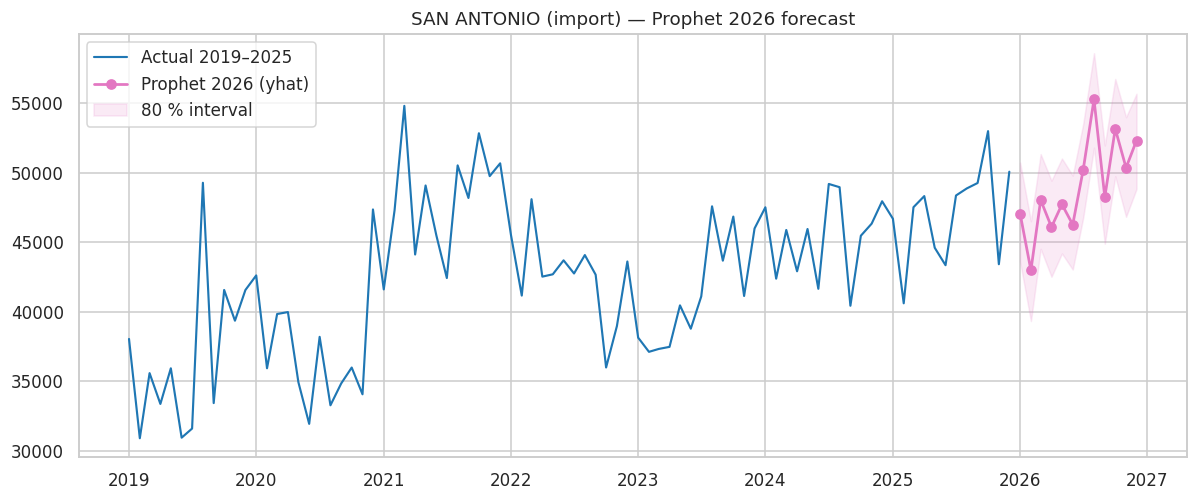

,ds,yhat,yhat_lower,yhat_upper
203,2026-01-01,47046.236426,43583.398054,50725.029352
204,2026-02-01,42977.958001,39327.035700,46511.732400
205,2026-03-01,48031.505336,44518.237560,51329.567058
206,2026-04-01,46088.374107,42514.384433,49422.981591
207,2026-05-01,47717.411653,44188.212027,51017.843951
208,2026-06-01,46265.523016,43032.157340,49791.075938
209,2026-07-01,50202.939463,46759.942679,53485.024278
210,2026-08-01,55267.720426,51791.853467,58588.138966
211,2026-09-01,48244.080884,44890.611943,51953.738424
212,2026-10-01,53150.523756,49741.312019,56737.810651


In [11]:
# 2026 = 12 monthly periods after the last training row in (max train year, 2025)
df_train_2025 = df_port[(~df_port["year"].isin(U.COVID_YEARS)) &
                         (df_port["year"] <= 2025)].copy()
ts26 = df_train_2025[["year","month",U.TARGET]].copy()
ts26["ds"] = pd.to_datetime(ts26[["year","month"]].assign(day=1))
ts26["y"]  = ts26[U.TARGET].astype(float)
ts26 = ts26[["ds","y"]].sort_values("ds")

m26 = Prophet(**PROPHET_PARAMS, changepoints=COVID_CHANGEPOINTS)
m26.fit(ts26)
future26 = m26.make_future_dataframe(periods=12, freq="MS")
fc26 = m26.predict(future26)
fc26_2026 = fc26[fc26["ds"].dt.year == 2026]

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2019, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual 2019–2025")
ax.plot(fc26_2026["ds"], fc26_2026["yhat"], "o-", color="#e377c2",
        lw=1.8, label="Prophet 2026 (yhat)")
ax.fill_between(fc26_2026["ds"], fc26_2026["yhat_lower"], fc26_2026["yhat_upper"],
                color="#e377c2", alpha=0.15, label="80 % interval")
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — Prophet 2026 forecast")
ax.legend()
plt.savefig(FIG_DIR / "73_prophet_2026.png")
plt.show()
fc26_2026[["ds","yhat","yhat_lower","yhat_upper"]]


## 7.8  2026 forecast — top-8 ports by volume

12:21:34 - cmdstanpy - INFO - Chain [1] start processing


12:21:34 - cmdstanpy - INFO - Chain [1] done processing


12:21:34 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


12:21:34 - cmdstanpy - INFO - Chain [1] start processing


...

12:21:35 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


12:21:35 - cmdstanpy - INFO - Chain [1] start processing


12:21:35 - cmdstanpy - INFO - Chain [1] done processing


Forecasted 8 port-direction pairs in 1.5s


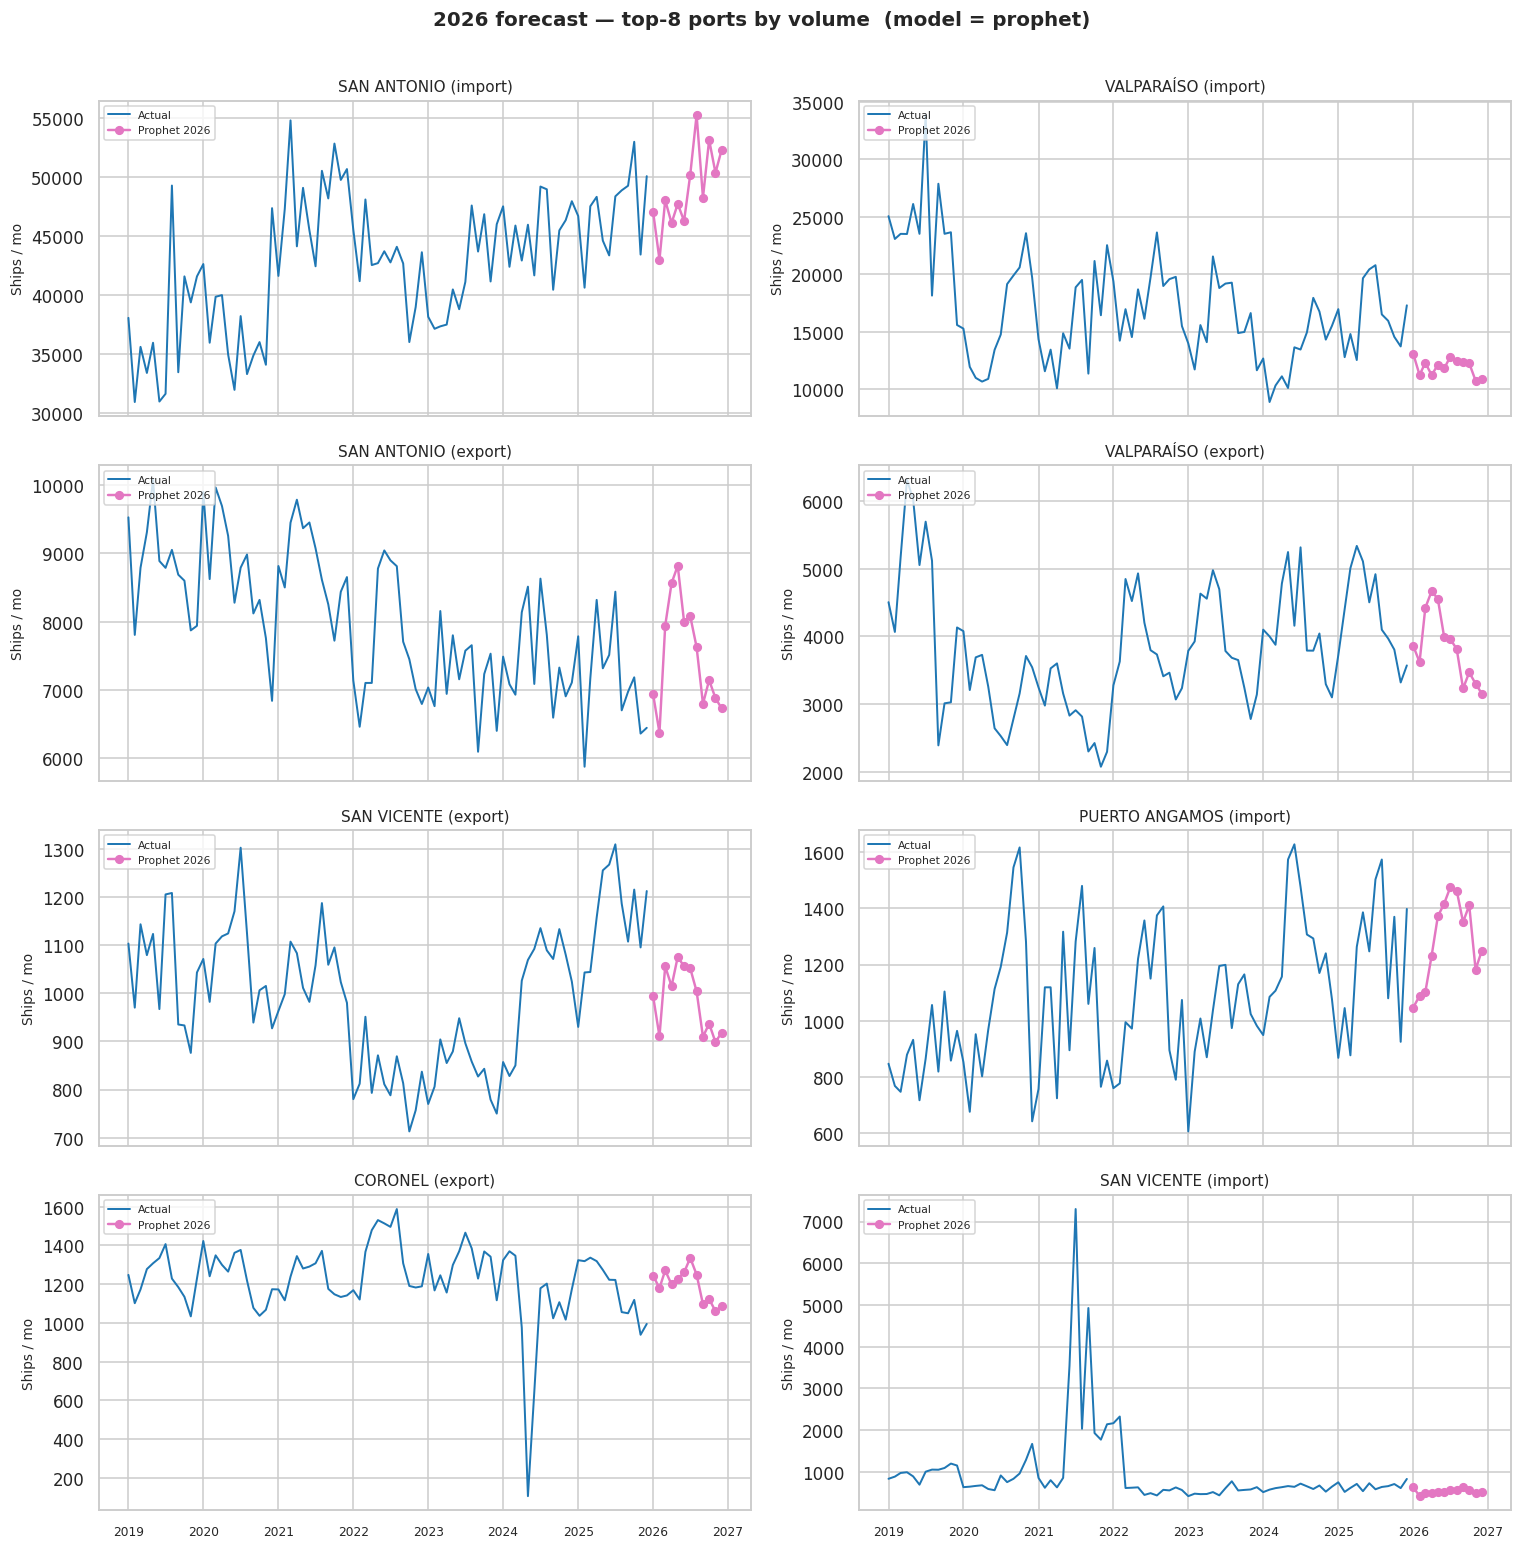

In [12]:
top8_volume = (df_panel.groupby(["port","direction"])[U.TARGET]
                       .mean().sort_values(ascending=False).head(8)
                       .reset_index())
top8_keys = list(zip(top8_volume["port"], top8_volume["direction"]))

import time as _time
_t0 = _time.time()
all_fc = []
for port, direction in top8_keys:
    _dp = U.get_port_panel(df_panel, port, direction)
    _tr = _dp[(~_dp["year"].isin(U.COVID_YEARS)) & (_dp["year"] <= 2025)].copy()
    ts = _tr[["year","month",U.TARGET]].copy()
    ts["ds"] = pd.to_datetime(ts[["year","month"]].assign(day=1))
    ts["y"]  = ts[U.TARGET].astype(float)
    ts = ts[["ds","y"]].sort_values("ds")
    if len(ts) < 24:
        continue
    _min_ds, _max_ds = ts["ds"].min(), ts["ds"].max()
    _valid_cp = [c for c in COVID_CHANGEPOINTS if pd.Timestamp(c) >= _min_ds and pd.Timestamp(c) <= _max_ds]
    _m = Prophet(**PROPHET_PARAMS, **({"changepoints": _valid_cp} if _valid_cp else {}))
    _m.fit(ts)
    _fut = _m.make_future_dataframe(periods=12, freq="MS")
    _pred = _m.predict(_fut)
    _p26 = _pred[_pred["ds"].dt.year == 2026][["ds","yhat"]].copy()
    _p26["year"]  = _p26["ds"].dt.year
    _p26["month"] = _p26["ds"].dt.month
    _p26["pred_shipment_count"] = np.maximum(1.0, _p26["yhat"])
    _p26["port"] = port; _p26["direction"] = direction
    all_fc.append(_p26)
fc_top8 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
print(f"Forecasted {len(top8_keys)} port-direction pairs in {_time.time()-_t0:.1f}s")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for ax, (port, direction) in zip(axes.flatten(), top8_keys):
    _dp = U.get_port_panel(df_panel, port, direction)
    hist = _dp[_dp["year"].between(2019, 2025)]
    hist_d = pd.to_datetime(hist[["year","month"]].assign(day=1))
    ax.plot(hist_d, hist[U.TARGET], color="#1f77b4", lw=1.3, label="Actual")

    sub = fc_top8[(fc_top8["port"] == port) & (fc_top8["direction"] == direction)]
    if len(sub):
        d2 = pd.to_datetime(sub[["year","month"]].assign(day=1))
        ax.plot(d2, sub["pred_shipment_count"], "o-",
                color="#e377c2", lw=1.6, markersize=5, label="Prophet 2026")
    ax.set_title(f"{port} ({direction})", fontsize=10)
    ax.set_ylabel("Ships / mo", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=7, loc="upper left")
plt.suptitle("2026 forecast — top-8 ports by volume  (model = prophet)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "74_prophet_top8_2026.png")
plt.show()


## 7.9  Take-aways

1. Prophet's only inputs are date and target value. The fact that it
   gets within striking distance of LightGBM (visible in notebook 08)
   tells us that **monthly seasonality + a COVID-aware trend** capture
   the bulk of the predictable signal.
2. The component plots are an excellent **storytelling tool** for the
   thesis defence — they show what is and is not predictable in plain
   English.
3. The MAPE gap between Prophet and LightGBM is the **value of the
   multivariate cargo-mix and diversity features**. If the gap is large
   (it is, in production), the feature engineering layer is justified.
4. Prophet's slow training time (≈ 1–3 s per port) is the main reason it
   is not used in production for 78 ports — and the reason this notebook
   is restricted to the top 12.
